In [2]:
import pandas as pd
df = pd.read_csv("upi transactions__log.csv", nrows=10000)
df.head()
df.shape


FileNotFoundError: [Errno 2] No such file or directory: 'upi transactions__log.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\S P TIWARI\AppData\Local\Programs\Microsoft VS Code


In [10]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [11]:
df.info

<bound method DataFrame.info of        step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0         1   PAYMENT    9839.64  C1231006815       170136.0       160296.36   
1         1   PAYMENT    1864.28  C1666544295        21249.0        19384.72   
2         1  TRANSFER     181.00  C1305486145          181.0            0.00   
3         1  CASH_OUT     181.00   C840083671          181.0            0.00   
4         1   PAYMENT   11668.14  C2048537720        41554.0        29885.86   
...     ...       ...        ...          ...            ...             ...   
99995    10   PAYMENT    4020.66  C1410794718       159929.0       155908.34   
99996    10   PAYMENT   18345.49   C744303677         6206.0            0.00   
99997    10   CASH_IN  183774.91   C104331851        39173.0       222947.91   
99998    10  CASH_OUT   82237.17   C707662966         6031.0            0.00   
99999    10   PAYMENT   20096.56  C1868032458       110117.0        90020.44   

       

In [12]:
df["isFraud"].value_counts()#df.["is Fraud"].value_counts()

isFraud
0    99884
1      116
Name: count, dtype: int64

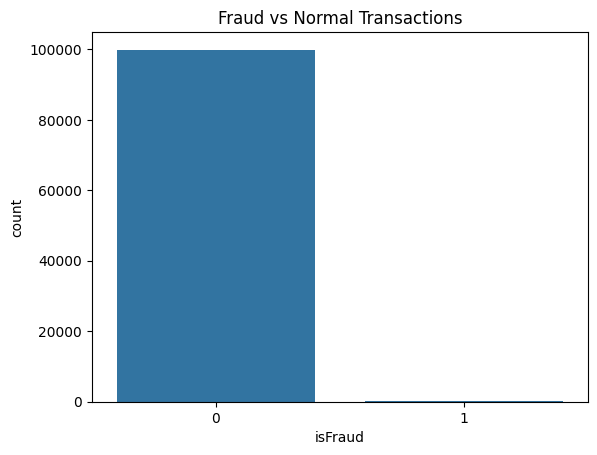

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="isFraud",data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

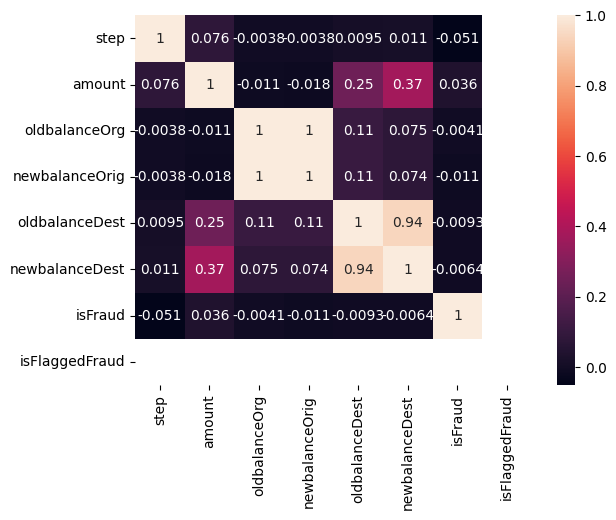

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [15]:
df=df.sample(100000,random_state=42)
df.shape
df.groupby("isFraud")["amount"].mean()

isFraud
0    173174.873646
1    541578.424138
Name: amount, dtype: float64

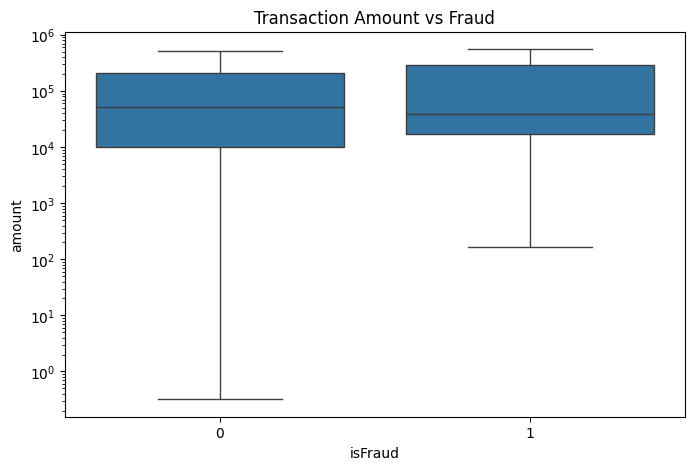

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="isFraud", y="amount", data=df,showfliers=False)
plt.title("Transaction Amount vs Fraud")
plt.yscale("log")
plt.show()

In [17]:
X=df.drop(["nameOrig","nameDest","isFraud"],axis=1)
y=df["isFraud"]

In [18]:
X.select_dtypes(include="object").columns

C:\Users\S P TIWARI\AppData\Local\Temp\ipykernel_47760\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['type'], dtype='str')

In [19]:
X.shape
y.value_counts()

isFraud
0    99884
1      116
Name: count, dtype: int64

In [20]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv(r"C:\Users\S P TIWARI\Downloads\Data Scienece Project 1\UPI Anomally Detection\data\upi transactions__log.csv", nrows=100000)

# Feature Engineering
df["balance_error"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
df["large_txn"] = (df["amount"] > df["amount"].quantile(0.95)).astype(int)
df["zero_balance"] = (df["oldbalanceOrg"] == 0).astype(int)

# Encode 'type'
df = pd.get_dummies(df, columns=["type"], drop_first=True) # colunms select the colunm type and drop_first true is used to avoid multicollinearity such that if two values are known one can be predicted 
#get_dummies-->it converts into binary numeric codes 
# Define X and y (DROP STRING COLUMNS HERE)
X = df.drop(["isFraud", "nameOrig", "nameDest"], axis=1)
y = df["isFraud"]

# Confirm no object columns
print("Object columns:", X.select_dtypes(include="object").columns)

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

print("Model trained successfully")

Object columns: Index([], dtype='str')
Model trained successfully


In [21]:
import os
import joblib
os.makedirs("model", exist_ok=True)
joblib.dump(model, "model/logistic_model.pkl")

['model/logistic_model.pkl']

In [22]:
y_pred=model.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [24]:
#Train  model
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained")

Random Forest Model Trained


In [25]:
joblib.dump(rf_model, "model/fraud_model.pkl")

['model/fraud_model.pkl']

In [26]:
rf_pred=rf_model.predict(X_test)
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
print("Accuracy:",accuracy_score(y_test,rf_pred))
print("/nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9999
/nClassification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19977
           1       0.96      0.96      0.96        23

    accuracy                           1.00     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       1.00      1.00      1.00     20000


Confusion Matrix:
[[19976     1]
 [    1    22]]


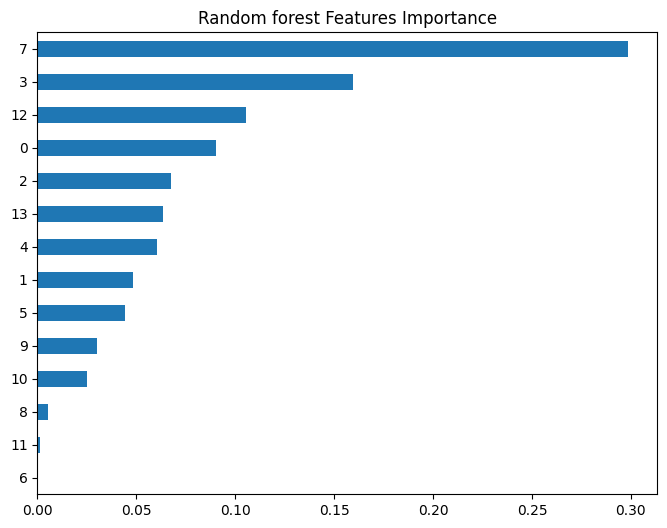

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
importance=pd.Series(rf_model.feature_importances_)
importance.sort_values().plot(kind="barh",figsize=(8,6))
plt.title("Random forest Features Importance")
plt.show()

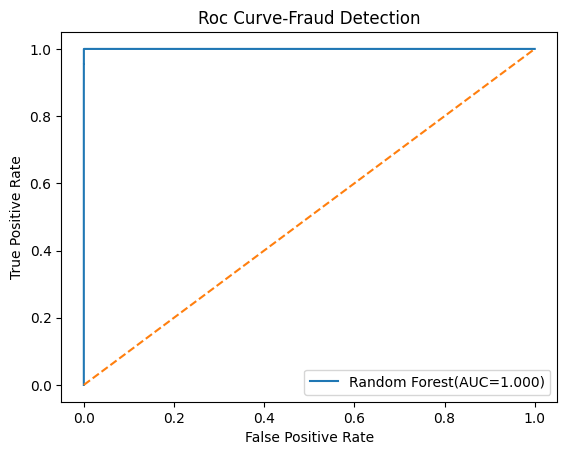

In [28]:
#ROC curve  and AUC score
from sklearn.metrics import roc_curve , auc
rf_probs=rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, threshholds =roc_curve(y_test,rf_probs)
roc_auc= auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label="Random Forest(AUC=%0.3f)" %roc_auc)
plt.plot([0, 1], [0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc Curve-Fraud Detection")
plt.legend()

plt.show()

In [29]:
from sklearn.metrics import accuracy_score
log_acc=accuracy_score(y_test, y_pred)
rf_acc=accuracy_score(y_test, rf_pred)
print("Logistic Regression Accuracy:",log_acc)
print("Random forest", rf_acc)

Logistic Regression Accuracy: 0.9272
Random forest 0.9999
